In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

user_data = pd.read_csv('user_data.csv')
dp003_math = pd.read_csv('dp003_math.csv')
dp003_math['game_time_seconds'] = dp003_math['game_time'] / 1000


In [3]:
# 分群計算每個 unit_name 和 game_grade 的 game_time 平均值
grouped_avg_time = dp003_math.groupby(['unit_name', 'game_grade'])['game_time_seconds'].mean().reset_index()
grouped_avg_time.set_index('unit_name', inplace=True)
grouped_avg_time

,game_grade,game_time_seconds
unit_name,,
10000以內的數,3,20.544731
1000以內的數,2,31.306556
100以內的數,1,12.713000
10以內的加減,1,14.306115
10以內的數,1,9.236578
20以內的加減,1,15.295900
30以內的數,1,1.158565
一億以內的數,4,8.024333
乘法,3,25.940421


dp003math的學生有闖關的遊戲單元，及其對應的適合年級與平均答題時間

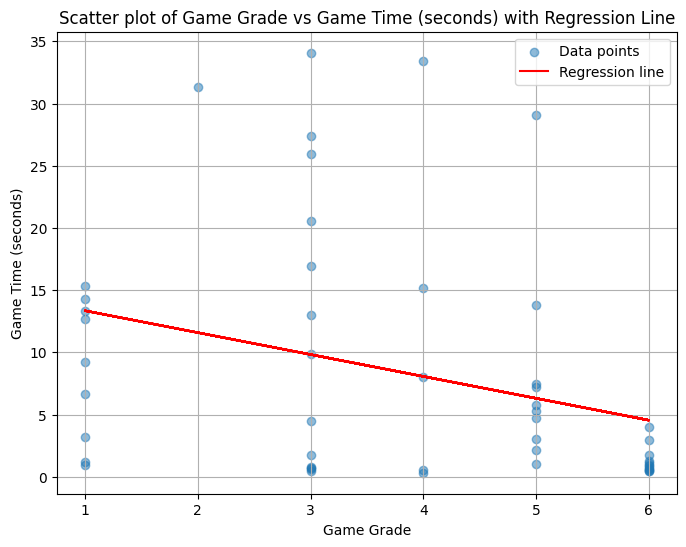

In [6]:

# 計算散佈圖中 game_time_sec 的統計數據（四分位數），以檢測極端值
# 設定四分位數界限來定義極端值
Q1 = grouped_avg_time['game_time_seconds'].quantile(0.25)
Q3 = grouped_avg_time['game_time_seconds'].quantile(0.75)
IQR = Q3 - Q1

# 設定極端值的界限（小於 Q1 - 1.5 * IQR 或大於 Q3 + 1.5 * IQR 的數據視為極端值）
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

grouped_avg_time_no_outliers = grouped_avg_time[(grouped_avg_time['game_time_seconds'] >= lower_bound) & (grouped_avg_time['game_time_seconds'] <= upper_bound)]

# 進行回歸分析，並在散佈圖中加入回歸線
from sklearn.linear_model import LinearRegression

# 設定 X 和 y
X = grouped_avg_time_no_outliers[['game_grade']]
y = grouped_avg_time_no_outliers['game_time_seconds']

# 建立線性回歸模型
model = LinearRegression()
model.fit(X, y)

# 預測值，以繪製回歸線
y_pred = model.predict(X)

# 繪製散佈圖及回歸線
plt.figure(figsize=(8, 6))
plt.scatter(grouped_avg_time_no_outliers['game_grade'], grouped_avg_time_no_outliers['game_time_seconds'], alpha=0.5, label='Data points')
plt.plot(grouped_avg_time_no_outliers['game_grade'], y_pred, color='red', label='Regression line')
plt.title('Scatter plot of Game Grade vs Game Time (seconds) with Regression Line')
plt.xlabel('Game Grade')
plt.ylabel('Game Time (seconds)')
plt.legend()
plt.grid(True)
plt.show()



In [7]:
# 執行線性回歸分析並獲取斜率的 t 檢定結果
import statsmodels.api as sm

# 設定 X 和 y，並加入常數項
X = sm.add_constant(grouped_avg_time_no_outliers['game_grade'])  # 加入常數項
y = grouped_avg_time_no_outliers['game_time_seconds']

# 執行線性回歸
model = sm.OLS(y, X).fit()

# 顯示回歸結果
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:      game_time_seconds   R-squared:                       0.102
Model:                            OLS   Adj. R-squared:                  0.083
Method:                 Least Squares   F-statistic:                     5.459
Date:                Thu, 31 Oct 2024   Prob (F-statistic):             0.0237
Time:                        18:05:16   Log-Likelihood:                -181.79
No. Observations:                  50   AIC:                             367.6
Df Residuals:                      48   BIC:                             371.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         15.1050      3.181      4.749      0.0

p-value = 0.024 < 0.25

所以遊戲適合年級對答題時間有顯著差異

In [8]:
filtered_data = dp003_math[['user_sn', 'game_grade', 'unit_id', 'unit_name', 'is_correct', 'game_time_seconds']]

# 以 user_sn 和 game_grade 分組，計算各欄位的所需統計量
grouped_data = filtered_data.groupby(['user_sn', 'game_grade', 'unit_id', 'unit_name']).agg(
    total_questions=('is_correct', 'count'),        # 總題數
    correct_answers=('is_correct', 'sum'),          # 正確答題數總和
    avg_game_time=('game_time_seconds', 'mean')     # 平均作答時間
).reset_index()

# 計算答對率並四捨五入至小數點後兩位
grouped_data['correct_rate'] = (grouped_data['correct_answers'] / grouped_data['total_questions']).round(2)

# 合併 math_score
user_data_filtered = user_data[['user_sn', 'math_score']]
merged_data = pd.merge(grouped_data, user_data_filtered, on='user_sn', how='left')
merged_data

,user_sn,game_grade,unit_id,unit_name,total_questions,correct_answers,avg_game_time,correct_rate,math_score
0,2697,1,1,10以內的數,1,1,20.027000,1.00,52
1,2697,3,1,數線,11,10,28.663273,0.91,52
2,2697,3,2,10000以內的數,21,19,43.196476,0.90,52
3,2697,4,5,體積：立方公分,28,16,41.840536,0.57,52
4,4561,1,5,10以內的加減,10,6,4.582700,0.60,56
...,...,...,...,...,...,...,...,...,...
118,312031,1,2,比較物品的長短,9,9,15.374111,1.00,68
119,312031,1,3,排順序、比多少,102,88,11.970020,0.86,68
120,312031,6,5,怎樣解題,76,27,0.935671,0.36,68
121,313378,1,1,10以內的數,58,25,4.598483,0.43,36


計算dp003的每位學生在進行每個遊戲後，個別單元的總答題數、答對數、答題平均時間、答對率

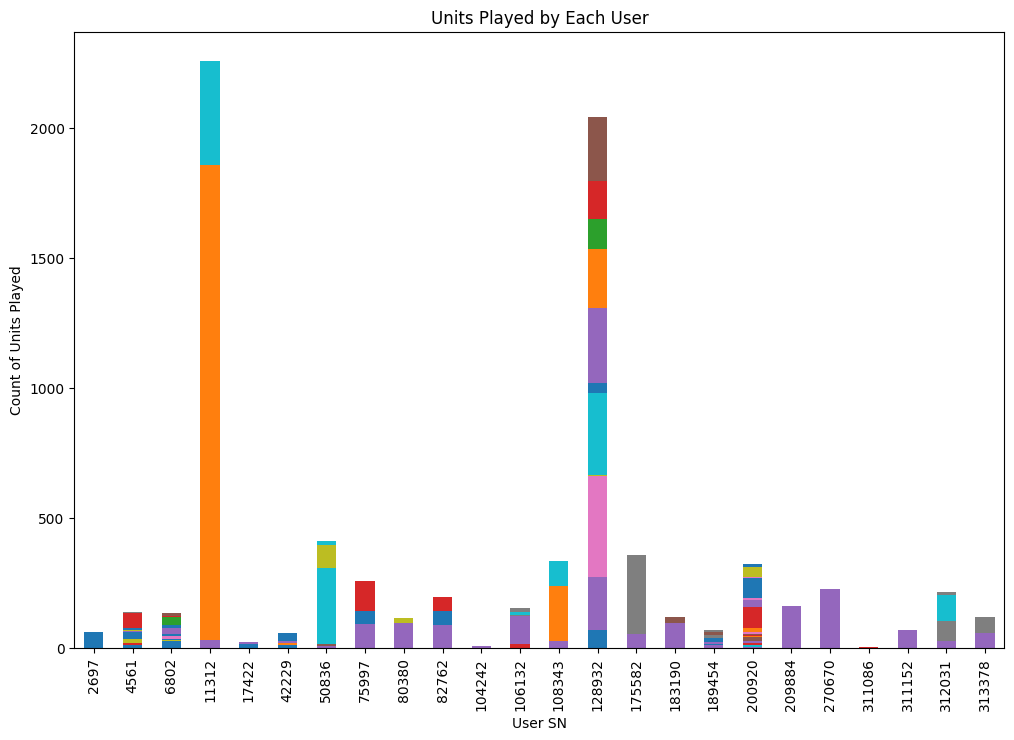

In [9]:
# Count the number of occurrences of each unit_name for each user_sn
user_unit_counts = dp003_math.groupby(['user_sn', 'unit_name']).size().unstack(fill_value=0)

# Plotting the bar chart for each user's units played
user_unit_counts.plot(kind='bar', stacked=True, figsize=(12, 8))
plt.xlabel('User SN')
plt.ylabel('Count of Units Played')
plt.title('Units Played by Each User')
# plt.tight_layout()
plt.legend().remove()
plt.show()


每個學生做的單元數量

In [23]:
# Group by user_sn and count the number of questions each user attempted
user_total_questions_df = dp003_math.groupby('user_sn').size().reset_index(name='total_questions')

# Calculate the total number of correct answers per user
user_correct_answers_df = dp003_math[dp003_math['is_correct'] == 1].groupby('user_sn').size().reset_index(name='correct_answers')

# Merge the total questions and correct answers dataframes
user_summary_df = pd.merge(user_total_questions_df, user_correct_answers_df, on='user_sn', how='left')
user_summary_df['correct_answers'] = user_summary_df['correct_answers'].fillna(0)  # Fill NaN values with 0 for users with no correct answers

# Calculate the correct answer rate
user_summary_df['correct_answer_rate'] = (user_summary_df['correct_answers'] / user_summary_df['total_questions']) * 100

user_summary_df['correct_answer_rate'] = user_summary_df['correct_answer_rate'].round(2)

user_summary_df = pd.merge(user_summary_df, user_data[['user_sn', 'math_score']], on='user_sn', how='left')
user_summary_df

,user_sn,total_questions,correct_answers,correct_answer_rate,math_score
0,2697,61,46,75.41,52
1,4561,139,102,73.38,56
2,6802,135,55,40.74,60
3,11312,2257,656,29.07,72
4,17422,22,19,86.36,60
5,42229,55,25,45.45,44
6,50836,412,114,27.67,68
7,75997,256,214,83.59,52
8,80380,115,60,52.17,32
9,82762,196,149,76.02,24


計算dp003的每位學生在進行的遊戲後，所有單元的總答題數和、答對數和、答題平均時間、答對率

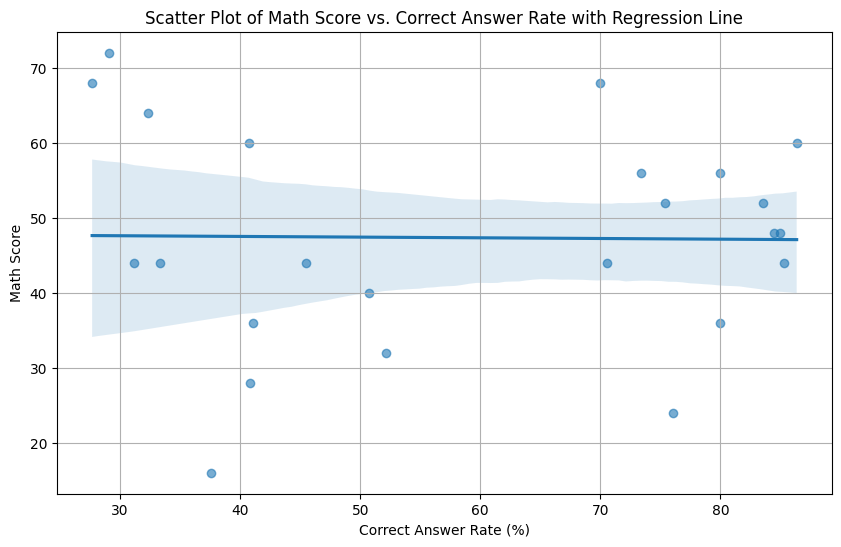

In [28]:
# Plot scatter plot with regression line
plt.figure(figsize=(10, 6))
sns.regplot(x='correct_answer_rate', y='math_score', data=user_summary_df, scatter_kws={'alpha':0.6})
plt.title("Scatter Plot of Math Score vs. Correct Answer Rate with Regression Line")
plt.xlabel("Correct Answer Rate (%)")
plt.ylabel("Math Score")
plt.grid(True)
plt.show()

dp003的學生的總答對率與數學成績沒有太大相關（總答對率ＶＳ數學成績）

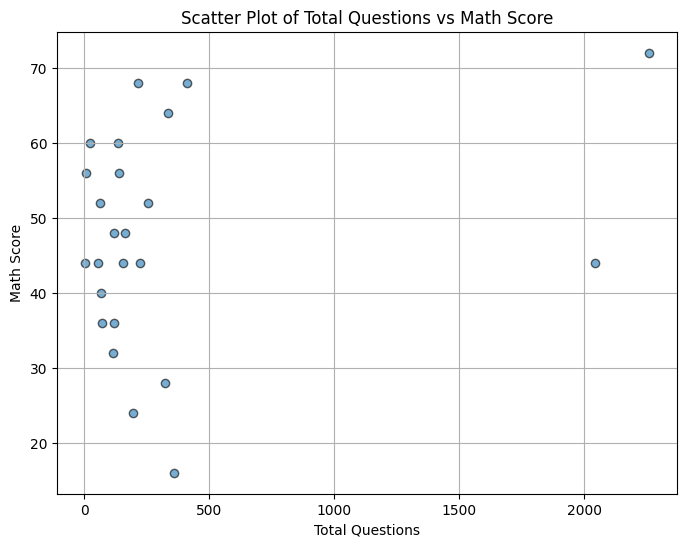

In [30]:
# Plot scatter plot between total attempts and math score to visualize their relationship
plt.figure(figsize=(8, 6))
plt.scatter(user_summary_df['total_questions'], user_summary_df['math_score'], alpha=0.6, edgecolor='k')
plt.title("Scatter Plot of Total Questions vs Math Score")
plt.xlabel("Total Questions")
plt.ylabel("Math Score")
plt.grid(True)
plt.show()

dp003的學生的總答題數與數學成績沒有太大相關（總答題數ＶＳ數學成績）

---

In [14]:
# Define a new mapping based on the refined TIMSS 2019 8th-grade math framework
# Using the defined framework categories: Number, Algebra, Geometry, Data and Probability

timss_8th_grade_mapping = {
    "數": {
        "整數": [
            '10以內的數', '1000以內的數', '10000以內的數', '100以內的數', '30以內的數', '一億以內的數'
        ],
        "分數與小數": [
            '分數：認識分數', '分數：異分母分數的加減', '分數、小數混合四則運算', '分數：擴分、約分和通分', 
            '分數：分數的除法', '分數：分數的乘法', '小數：小數的乘法', '小數：三位以下小數的除法'
        ],
        "比、比例與百分比": [
            '比、比值與成正比'
        ]
    },
    "代數": {
        "算式、運算和方程式": [
            '加減併式與估算', '乘法', '20以內的加減'
        ],
        "關係式與函數": [
            '最大公因數與最小公倍數'
        ]
    },
    "幾何": {
        "幾何形狀與測量": [
            '體積：立方公分', '認識形狀', '認識圓和角', '比較物品的長短', '柱體與椎體', '線對稱圖形', 
            '長方體、正多面體和球', '多邊形角度', '扇形', '時間：年月日時分秒運算', '面積', 
            '周界和周長', '圓的複合圖形', '圓周長、圓面積與扇形面積', '速度與速率', 
            '正方體與長方體的表面積', '角度', '認識三角形', '重量：公斤和公克', '容量：公升和毫升'
        ]
    },
    "數據與機率": {
        "資料": [
            '排順序、比多少', '統計圖表'
        ],
        "機率": []  # No explicit probability items found in the provided units
    }
}

# Flatten the mapping to create a dictionary that maps each unit_name to its refined TIMSS domain and subdomain
unit_to_timss_8th_grade = {
    unit: (main_domain, subdomain) 
    for main_domain, subdomains in timss_8th_grade_mapping.items()
    for subdomain, units in subdomains.items()
    for unit in units
}

# Create columns in the dataframe based on the refined classification
dp003_math['main_domain'] = dp003_math['unit_name'].map(lambda x: unit_to_timss_8th_grade.get(x, (None, None))[0])
dp003_math['subdomain'] = dp003_math['unit_name'].map(lambda x: unit_to_timss_8th_grade.get(x, (None, None))[1])

# Group by user_sn and main_domain, then count the number of entries for each student in each refined domain
student_refined_domain_counts = dp003_math.groupby(['user_sn', 'main_domain']).size().unstack(fill_value=0)
# Calculate the correct answer rate per main domain for each student
# First, filter out records based on whether the answer was correct
dp003_math['is_correct'] = dp003_math['is_correct'].fillna(0)  # Ensure no NaN in is_correct

# Only keep relevant columns: user_sn and math_score
user_data_df = user_data[['user_sn', 'math_score']]

# Merge the math_score data with the refined domain answer rate DataFrame by user_sn
dp003_math_with_score = dp003_math.merge(user_data_df, on='user_sn', how='left')

# Calculate domain counts and add math_score for each user
correct_counts = dp003_math_with_score.groupby(['user_sn', 'main_domain'])['is_correct'].sum()
total_counts = dp003_math_with_score.groupby(['user_sn', 'main_domain'])['is_correct'].count()
answer_rate = (correct_counts / total_counts).unstack(fill_value=0)

# Add math_score to the answer rate DataFrame
answer_rate = answer_rate.merge(user_data_df.set_index('user_sn'), left_index=True, right_index=True)
answer_rate


,代數,幾何,數,數據與機率,math_score
user_sn,,,,,
2697,0.000000,0.571429,0.909091,0.000000,52
4561,0.538462,0.820896,0.900000,0.000000,56
6802,0.666667,0.328358,0.450000,0.000000,60
11312,0.000000,0.259352,0.297414,0.000000,72
17422,0.000000,1.000000,0.909091,0.000000,60
42229,0.000000,0.000000,0.625000,0.000000,44
50836,0.700000,0.267123,0.200000,0.200000,68
75997,0.000000,0.859649,0.934066,0.000000,52
80380,0.157895,0.000000,0.593750,0.000000,32


把每個dp003的學生做的單元依照TIMSS2019報告的'數'、'代數'、'幾何'、'資料與機率'四個主題做分配

並計算每個主題的答對率，最後增加一欄表示數學測驗成績

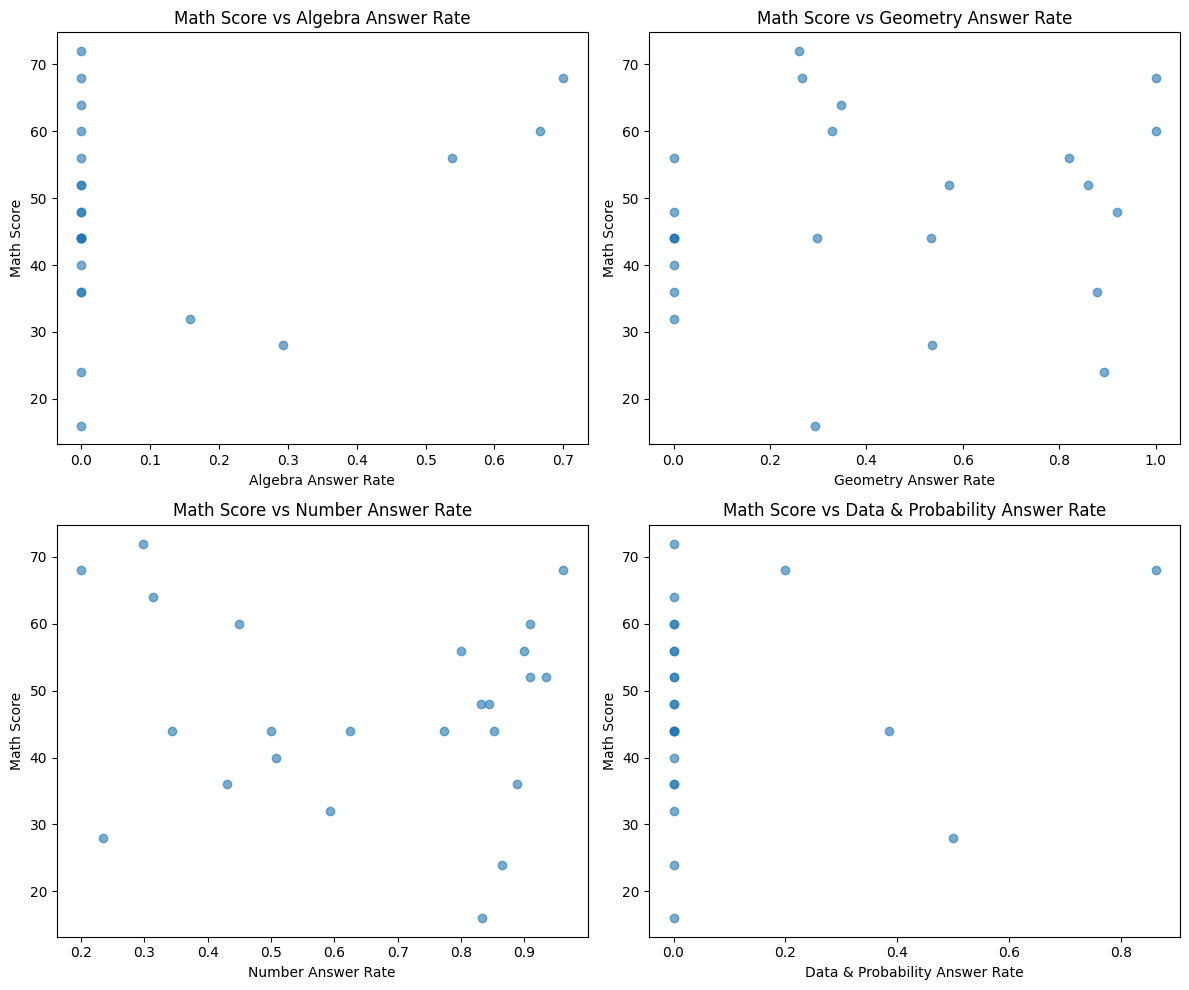

In [15]:
# Preparing data for each domain's answer rate and the math_score
domains = ["代數", "幾何", "數", "數據與機率"]
x_labels = ["Algebra Answer Rate", "Geometry Answer Rate", "Number Answer Rate", "Data & Probability Answer Rate"]
y_label = "Math Score"

# Generate subplots in a 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()  # Flatten to easily iterate over the axes

# Plot each scatter plot in the respective subplot
for i, domain in enumerate(domains):
    # Filter non-null data for answer rate and math score in the current domain
    x_data = answer_rate[domain]
    y_data = answer_rate['math_score']
    
    # Plot on the i-th axis
    axes[i].scatter(x_data, y_data, alpha=0.6)
    axes[i].set_xlabel(x_labels[i])
    axes[i].set_ylabel(y_label)
    axes[i].set_title(f"Math Score vs {x_labels[i]}")

# Adjust layout for better spacing
plt.tight_layout()
plt.show()


每個學生做的主題對應其數學成績，沒有相關性，直觀上表示某個主題的答對率隊數學成績沒有相關性


In [16]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

# Prepare the dataset for regression
# Select students who have attempted questions in at least one of the four domains
filtered_df = dp003_math[dp003_math['main_domain'].notna()]

# Aggregate the answer rates by user_sn and main domain (calculate average answer rate per domain)
answer_rates_by_domain = filtered_df.groupby(['user_sn', 'main_domain'])['is_correct'].mean().unstack(fill_value=0)

# Merge with math_score
regression_data = answer_rates_by_domain.merge(user_data_df.set_index('user_sn'), left_index=True, right_index=True)

# Extracting features (answer rates for the four domains) and target variable (math_score)
X = regression_data[['數', '代數', '幾何', '數據與機率']]
y = regression_data['math_score']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and fit the linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Calculate regression metrics
r_squared = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

# Retrieve regression coefficients
coefficients = model.coef_

# Organize the regression results as a DataFrame for clear presentation
# Retrieve the regression coefficients, R-squared, and Mean Squared Error for display

# Define the regression data
domain_contributions = pd.DataFrame({
    'Domain': X.columns, 
    'Coefficient': coefficients
})

# Add R-squared and MSE as additional rows to give a comprehensive overview
model_metrics = pd.DataFrame([
    {"Domain": "R-squared", "Coefficient": r_squared},
    {"Domain": "Mean Squared Error", "Coefficient": mse}
])

# Append the metrics to the domain coefficients table
regression_results = pd.concat([domain_contributions, model_metrics], ignore_index=True)
regression_results

,Domain,Coefficient
0,數,-8.246387
1,代數,13.930696
2,幾何,7.058670
3,數據與機率,5.655780
4,R-squared,-0.582477
5,Mean Squared Error,87.099545


In [17]:
import statsmodels.api as sm

# Add a constant term (intercept) to the model for the statsmodels regression analysis
X_with_intercept = sm.add_constant(X)

# Fit the regression model using statsmodels for access to p-values and t-values
model_sm = sm.OLS(y, X_with_intercept).fit()

# Retrieve the summary as a table with coefficients, standard errors, t-values, and p-values
significance_results = model_sm.summary2().tables[1]
significance_results


,Coef.,Std.Err.,t,P>|t|,[0.025,0.975]
const,47.747644,10.005823,4.771986,0.000133,26.805216,68.690071
數,-7.251926,15.600586,-0.464850,0.647322,-39.904328,25.400477
代數,13.873114,15.708568,0.883156,0.388190,-19.005297,46.751524
幾何,6.164984,10.424124,0.591415,0.561214,-15.652959,27.982926
數據與機率,5.907712,15.891956,0.371742,0.714198,-27.354534,39.169957


In [18]:
# Calculate overall answer rate (total correct answers / total attempts) for each student
# Group by user_sn to get total correct answers and total attempts
total_correct_answers = dp003_math.groupby('user_sn')['is_correct'].sum()
total_attempts = dp003_math.groupby('user_sn')['is_correct'].count()

# Calculate overall answer rate
overall_answer_rate = total_correct_answers / total_attempts

# Merge overall answer rate with math_score from user_data
overall_data = pd.DataFrame({
    'overall_answer_rate': overall_answer_rate,
    'total_attempts': total_attempts
}).merge(user_data_df.set_index('user_sn'), left_index=True, right_index=True)

# Prepare features and target for regression
X_overall = overall_data[['overall_answer_rate', 'total_attempts']]
y_overall = overall_data['math_score']

# Split the data into training and testing sets
X_train_overall, X_test_overall, y_train_overall, y_test_overall = train_test_split(X_overall, y_overall, test_size=0.2, random_state=42)

# Fit a linear regression model
model_overall = LinearRegression()
model_overall.fit(X_train_overall, y_train_overall)

# Predict and calculate performance metrics
y_pred_overall = model_overall.predict(X_test_overall)
r_squared_overall = r2_score(y_test_overall, y_pred_overall)
mse_overall = mean_squared_error(y_test_overall, y_pred_overall)

# Retrieve regression coefficients and intercept
overall_coefficients = model_overall.coef_
overall_intercept = model_overall.intercept_

# Compile results into a DataFrame
overall_results = pd.DataFrame({
    'Variable': ['Overall Answer Rate', 'Total Attempts', 'Intercept'],
    'Coefficient': list(overall_coefficients) + [overall_intercept]
})

# Add R-squared and MSE as additional metrics
metrics_overall = pd.DataFrame([
    {"Variable": "R-squared", "Coefficient": r_squared_overall},
    {"Variable": "Mean Squared Error", "Coefficient": mse_overall}
])

# Append metrics to the overall regression results
overall_results = pd.concat([overall_results, metrics_overall], ignore_index=True)
overall_results


,Variable,Coefficient
0,Overall Answer Rate,8.954413
1,Total Attempts,0.006602
2,Intercept,41.157704
3,R-squared,-0.501355
4,Mean Squared Error,82.634556


分析每位學生的總答題數與答對率對數學成績的關係

總答對率對數學成績有正向影響

總答題數對數學成績影響較小


整體而言，負的R^2無法解釋這兩個變數對數學成績的變異

且較高的MSE表示模型的預測度不大，誤差會較大

總答題數 VS 數學成績

In [21]:
from sklearn.preprocessing import PolynomialFeatures

# Define the original features (answer rates for the four domains)
X_interactions = answer_rates_by_domain[['數', '代數', '幾何', '數據與機率']]

# Use PolynomialFeatures to generate interaction terms (degree 2 only includes pairwise interactions)
poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
X_interactions_poly = poly.fit_transform(X_interactions)

# Convert interaction terms back to a DataFrame with appropriate column names
interaction_feature_names = poly.get_feature_names_out(X_interactions.columns)
X_interactions_df = pd.DataFrame(X_interactions_poly, columns=interaction_feature_names, index=X_interactions.index)

# Merge the new interaction features with the math_score for regression analysis
X_interactions_df = X_interactions_df.merge(user_data_df.set_index('user_sn')['math_score'], left_index=True, right_index=True)

# Separate features and target variable
X_interactions_final = X_interactions_df.drop(columns='math_score')
y_interactions_final = X_interactions_df['math_score']

# Fit a linear regression model on the features with interaction terms
model_interactions = LinearRegression()
model_interactions.fit(X_interactions_final, y_interactions_final)

# Retrieve regression coefficients and performance metrics
interaction_coefficients = model_interactions.coef_
interaction_intercept = model_interactions.intercept_
r_squared_interactions = model_interactions.score(X_interactions_final, y_interactions_final)

# Compile results into a DataFrame for easy review
interaction_results = pd.DataFrame({
    'Variable': interaction_feature_names,
    'Coefficient': interaction_coefficients
})

# Add intercept and R-squared to the table
interaction_results = pd.concat([pd.DataFrame([{'Variable': 'Intercept', 'Coefficient': interaction_intercept}]), interaction_results], ignore_index=True)
interaction_results = pd.concat([interaction_results, pd.DataFrame([{'Variable': 'R-squared', 'Coefficient': r_squared_interactions}])], ignore_index=True)
interaction_results

,Variable,Coefficient
0,Intercept,46.635424
1,數,-5.294210
2,代數,23.220052
3,幾何,58.377532
4,數據與機率,-218.289845
5,數 代數,-161.688641
6,數 幾何,-62.931524
7,數 數據與機率,286.494759
8,代數 幾何,177.718829
9,代數 數據與機率,120.184921


解釋這四個變項的交互作用，解釋力有46%S ，